      Task 3.1: Random Forest Grid Search
Nt= 25  Np=1  CV Accuracy: 0.8950
Nt= 25  Np=4  CV Accuracy: 0.9250
Nt= 25  Np=8  CV Accuracy: 0.9263
Nt= 75  Np=1  CV Accuracy: 0.9075
Nt= 75  Np=4  CV Accuracy: 0.9338
Nt= 75  Np=8  CV Accuracy: 0.9262
Nt=125  Np=1  CV Accuracy: 0.9088
Nt=125  Np=4  CV Accuracy: 0.9325
Nt=125  Np=8  CV Accuracy: 0.9262
Nt=175  Np=1  CV Accuracy: 0.9100
Nt=175  Np=4  CV Accuracy: 0.9338
Nt=175  Np=8  CV Accuracy: 0.9250
Nt=225  Np=1  CV Accuracy: 0.9088
Nt=225  Np=4  CV Accuracy: 0.9287
Nt=225  Np=8  CV Accuracy: 0.9262
Nt=275  Np=1  CV Accuracy: 0.9100
Nt=275  Np=4  CV Accuracy: 0.9338
Nt=275  Np=8  CV Accuracy: 0.9275
Nt=325  Np=1  CV Accuracy: 0.9112
Nt=325  Np=4  CV Accuracy: 0.9350
Nt=325  Np=8  CV Accuracy: 0.9275
Nt=375  Np=1  CV Accuracy: 0.9125
Nt=375  Np=4  CV Accuracy: 0.9350
Nt=375  Np=8  CV Accuracy: 0.9287
*************************

  Best: Nt=375  Np=4  Accuracy=0.9350
*************************


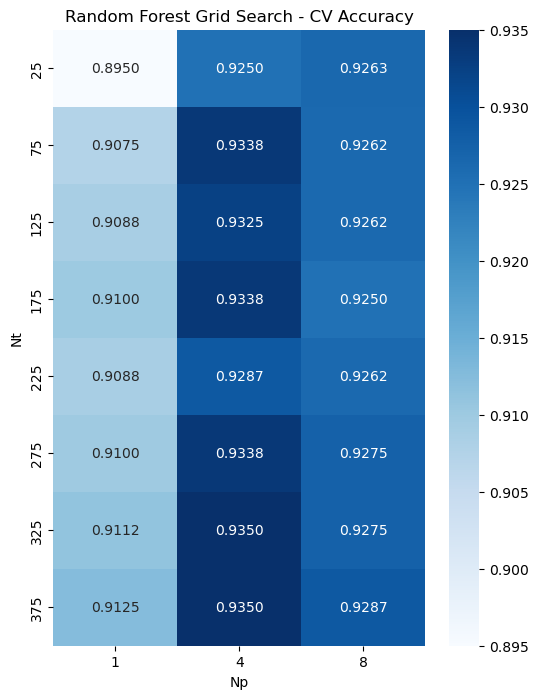

      Task 3.2: Random Forest Stability Check
Run  1  CV Accuracy: 0.9388
Run  2  CV Accuracy: 0.9350
Run  3  CV Accuracy: 0.9325
Run  4  CV Accuracy: 0.9325
Run  5  CV Accuracy: 0.9350
Run  6  CV Accuracy: 0.9325
Run  7  CV Accuracy: 0.9338
Run  8  CV Accuracy: 0.9350
Run  9  CV Accuracy: 0.9350
Run 10  CV Accuracy: 0.9350
Run 11  CV Accuracy: 0.9325
Run 12  CV Accuracy: 0.9363

Mean Accuracy : 0.9345
Std Deviation : 0.0019

t-statistic : 1490.5195
p-value     : 0.000000
Result: Model performs significantly better than chance (p < 0.05)
      Task 3.3: Final Model Evaluation on Test Set
Test Accuracy: 0.9600


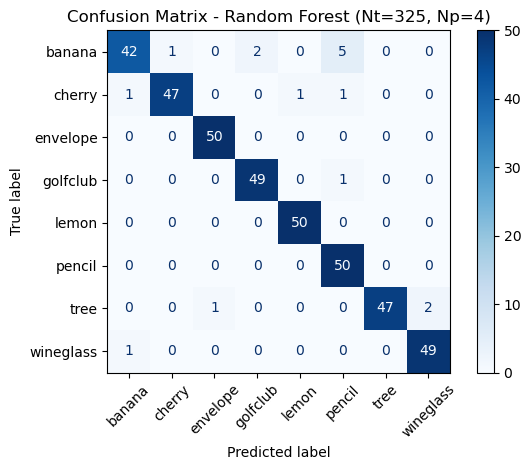

              precision    recall  f1-score   support

      banana       0.95      0.84      0.89        50
      cherry       0.98      0.94      0.96        50
    envelope       0.98      1.00      0.99        50
    golfclub       0.96      0.98      0.97        50
       lemon       0.98      1.00      0.99        50
      pencil       0.88      1.00      0.93        50
        tree       1.00      0.94      0.97        50
   wineglass       0.96      0.98      0.97        50

    accuracy                           0.96       400
   macro avg       0.96      0.96      0.96       400
weighted avg       0.96      0.96      0.96       400



In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import ttest_1samp
from sklearn.metrics import classification_report


def main():
    
    train_src = "C:\\Users\\ammar\\Desktop\\A2_Ammar_Jileidan\\Assignment2-Datas\\Assignment2-Datas\\Assignment2-Datas\\Train Datasets\\TrainDataset3\\all_features.csv"
    test_src = "C:\\Users\\ammar\\Desktop\\A2_Ammar_Jileidan\\Assignment2-Datas\\Assignment2-Datas\\Assignment2-Datas\\Test Datasets\\TestDataset2\\all_features.csv"
    

    col_names = ['label', 'index', 'nr_pix', 'rows_with_1', 'cols_with_1', 'rows_with_2',
             'cols_with_2', 'rows_with_3p', 'cols_with_3p', 'height', 'width',
             'aspect_ratio', 'maxrow', 'maxcol', 'connected_areas', 'eyes',
             'hollowness','custom']
    
    df_train = pd.read_csv(train_src, header=None, names=col_names)
    df_test = pd.read_csv(test_src, header=None, names=col_names)
    
    #========================================================================================================
    #Task 3.1
    #========================================================================================================

    print("="*55)
    print("      Task 3.1: Random Forest Grid Search")
    print("="*55)
    
    features = ['nr_pix', 'rows_with_1', 'cols_with_1', 'rows_with_2',
                  'cols_with_2', 'rows_with_3p', 'cols_with_3p', 'height', 'width',
                  'aspect_ratio', 'maxrow', 'maxcol', 'connected_areas', 'eyes', 'hollowness']
    
    X_train = df_train[features].values
    y_train = df_train['label'].values
    
    X_test  = df_test[features].values
    y_test  = df_test['label'].values
    
    Nt_values = [25, 75, 125, 175, 225, 275, 325, 375]
    Np_values  = [1, 4, 8]
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # store results
    results = []
    
    for Nt in Nt_values:
        for Np in Np_values:
            fold_acc = []
            
            for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
                X_tr = X_train[train_idx]
                X_val = X_train[val_idx]
                y_tr = y_train[train_idx]
                y_val = y_train[val_idx]
                
                rf = RandomForestClassifier(n_estimators=Nt, max_features=Np, random_state=42)
                rf.fit(X_tr, y_tr)
                y_pred = rf.predict(X_val)
                fold_acc.append(accuracy_score(y_val, y_pred))
            
            mean_acc = np.mean(fold_acc)
            results.append({'Nt': Nt, 'Np': Np, 'Accuracy': mean_acc})
            print(f"Nt={Nt:3d}  Np={Np}  CV Accuracy: {mean_acc:.4f}")
    
    # find best combination
    results_df = pd.DataFrame(results)
    best = results_df.loc[results_df['Accuracy'].idxmax()]
    
    print("*"*25)
    print(f"\n  Best: Nt={int(best['Nt'])}  Np={int(best['Np'])}  Accuracy={best['Accuracy']:.4f}")
    print("*"*25)
    
    pivot = results_df.pivot(index='Nt', columns='Np', values='Accuracy')
    
    plt.figure(figsize=(6, 8))
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='Blues')
    plt.title('Random Forest Grid Search - CV Accuracy')
    plt.xlabel('Np')
    plt.ylabel('Nt')
    plt.show()

    #========================================================================================================
    #Task 3.2
    #========================================================================================================
    
    print("="*55)
    print("      Task 3.2: Random Forest Stability Check")
    print("="*55)
    
    accuracies = []
    
    for seed in range(12):
        fold_acc = []
        
        for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
            X_tr  = X_train[train_idx]
            X_val = X_train[val_idx]
            y_tr  = y_train[train_idx]
            y_val = y_train[val_idx]
            
            rf = RandomForestClassifier(n_estimators=325, max_features=4, random_state=seed)
            rf.fit(X_tr, y_tr)
            y_pred = rf.predict(X_val)
            fold_acc.append(accuracy_score(y_val, y_pred))
        
        acc = np.mean(fold_acc)
        accuracies.append(acc)
        print(f"Run {seed+1:2d}  CV Accuracy: {acc:.4f}")
    
    mean_acc = np.mean(accuracies)
    std_acc  = np.std(accuracies, ddof=1)
    print(f"\nMean Accuracy : {mean_acc:.4f}")
    print(f"Std Deviation : {std_acc:.4f}")
    
    # one sample t-test against chance level (1/8 = 0.125)
    t_stat, p_value = ttest_1samp(accuracies, 0.125)
    print(f"\nt-statistic : {t_stat:.4f}")
    print(f"p-value     : {p_value:.6f}")
    
    if p_value < 0.05:
        print("Result: Model performs significantly better than chance (p < 0.05)")
    else:
        print("Result: No significant difference from chance (p >= 0.05)")

    #========================================================================================================
    #Task 3.3
    #========================================================================================================

    print("="*55)
    print("      Task 3.3: Final Model Evaluation on Test Set")
    print("="*55)
    
    # Train on full training set
    rf_final = RandomForestClassifier(n_estimators=325, max_features=4, random_state=42)
    rf_final.fit(X_train, y_train)
    
    # Test on test set
    y_pred_test = rf_final.predict(X_test)
    
    # Accuracy
    acc_test = accuracy_score(y_test, y_pred_test)
    print(f"Test Accuracy: {acc_test:.4f}")
    
    # Confusion matrix
    classes = sorted(df_train['label'].unique())
    cm = confusion_matrix(y_test, y_pred_test, labels=classes)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(cmap='Blues')
    plt.title('Confusion Matrix - Random Forest (Nt=325, Np=4)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


    print(classification_report(y_test, y_pred_test, target_names=classes))
    
main()